In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, collect_list, array_sort, explode
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from datetime import datetime, timedelta
import pandas as pd

import mlflow
mlflow.autolog(disable=True)


# Initialize Spark session
#spark = SparkSession.builder.appName("LogToWord2Vec").getOrCreate()
start_time = datetime(2024, 2, 23, 14, 0, 0)
end_time = start_time + timedelta(hours=1)

In [0]:
# Let's define a query for the data we want to collect
# Beside timestamp, we want to get:
#   * client_ip
#   * session, as cmcd_session_id if present, otherwise it will be a has value of client_ip and user_agent
#   * ua_category, as a group of user agents of similart family, inlcluding suspect such as headleas_browser or syntetic_browsers etc
#   * extension, as file extension form URL (.mp4, .ts, .m3u8, etc)
#   * bytes_out, Number of bytes per request
#   * cmcd_streaming_format as cmcd_sf

query = f"""
    SELECT 
        timestamp, 
        client_ip, 
        COALESCE(cmcd_session_id, HEX(CONCAT(client_ip, user_agent))) AS session,
        CASE
            WHEN lower(user_agent) LIKE '%headless%' 
                OR lower(user_agent) LIKE '%phantomjs%' 
                OR lower(user_agent) LIKE '%puppeteer%' 
                OR lower(user_agent) LIKE '%selenium%' 
                OR lower(user_agent) LIKE '%htmlunit%' 
                OR lower(user_agent) LIKE '%casperjs%' 
                OR lower(user_agent) LIKE '%slimerjs%' 
            THEN 'headless_browser'

            WHEN lower(user_agent) LIKE '%catchpoint%' 
                OR lower(user_agent) LIKE '%new relic%' 
                OR lower(user_agent) LIKE '%dynatrace%' 
                OR lower(user_agent) LIKE '%appdynamics%' 
                OR lower(user_agent) LIKE '%datadog%' 
                OR lower(user_agent) LIKE '%uptimerobot%' 
                OR lower(user_agent) LIKE '%pingdom%' 
                OR lower(user_agent) LIKE '%site24x7%' 
                OR lower(user_agent) LIKE '%uptrends%' 
                OR lower(user_agent) LIKE '%statuscake%' 
                OR lower(user_agent) LIKE '%touchstream%' 
                OR lower(user_agent) LIKE '%proximic%' 
                OR lower(user_agent) LIKE '%cfnetwork%' 
            THEN 'measurement_agent' 

            WHEN lower(user_agent) LIKE '%curl%' 
                OR lower(user_agent) LIKE '%wget%' 
                OR lower(user_agent) LIKE '%python-requests%' 
                OR lower(user_agent) LIKE '%httpie%' 
                OR lower(user_agent) LIKE '%okhttp%' 
                OR lower(user_agent) LIKE '%libcurl%' 
                OR lower(user_agent) LIKE '%postmanruntime%' 
                OR lower(user_agent) LIKE '%go-http-client%' 
            THEN 'synthetic_browser' 

            WHEN lower(user_agent) LIKE '%lavf%'
                OR lower(user_agent) LIKE '%kodi%'
                OR lower(user_agent) LIKE '%ffmpeg%'
                OR lower(user_agent) LIKE '%exoplayer%'
                OR lower(user_agent) LIKE '%openload%'
                OR lower(user_agent) LIKE '%libvlc%'
            THEN 'video_player'


            WHEN lower(user_agent) LIKE '%googlebot%' 
                OR lower(user_agent) LIKE '%bingbot%' 
                OR lower(user_agent) LIKE '%slurp%' 
                OR lower(user_agent) LIKE '%yandexbot%' 
                OR lower(user_agent) LIKE '%yandexrenderresourcesbot%' 
                OR lower(user_agent) LIKE '%baiduspider%' 
                OR lower(user_agent) LIKE '%duckduckbot%' 
                OR lower(user_agent) LIKE '%gogoduck%' 
            THEN 'web_crawler'

            WHEN lower(user_agent) LIKE '%google-videoads-stitching%' THEN 'video_crawler' 

            WHEN lower(user_agent) LIKE '%roku%' THEN 'roku' 

            WHEN lower(user_agent) LIKE '%iphone%' 
                OR lower(user_agent) LIKE '%ipod touch%' 
            THEN 'mobile_iphone'

            WHEN lower(user_agent) LIKE '%ipad%' THEN 'tablet_ios'

            WHEN lower(user_agent) LIKE '%mfi_airplay_device%' THEN 'airplay_apple' 

            WHEN lower(user_agent) LIKE '%android%' THEN 
                CASE 
                    WHEN lower(user_agent) LIKE '%mobile%' THEN 'mobile_android' 
                    ELSE 'tablet_android' 
                END

            WHEN lower(user_agent) LIKE '%smart-tv%' 
                OR lower(user_agent) LIKE '%hbbtv%' 
                OR lower(user_agent) LIKE '%appletv%' 
                OR lower(user_agent) LIKE '%apple tv%' 
                OR lower(user_agent) LIKE '%fetchtv%' 
                OR lower(user_agent) LIKE '%smartcast%' 
                OR lower(user_agent) LIKE '%firetv%' 
            THEN 'settop_box' 

            WHEN lower(user_agent) LIKE '%playstation%' 
                OR lower(user_agent) LIKE '%xbox%' 
                OR lower(user_agent) LIKE '%nintendo%' 
                OR lower(user_agent) LIKE '%apple vision%' 
            THEN 'gaming_console' 

            WHEN lower(user_agent) LIKE '%windows%' 
                OR lower(user_agent) LIKE '%macintosh%' 
                OR lower(user_agent) LIKE '%linux%' 
                OR lower(user_agent) LIKE '%x11%' 
                OR lower(user_agent) LIKE '%fuchsia%' 
            THEN 'desktop_browser'

            WHEN lower(user_agent) = '' THEN 'empty'
        ELSE 'other'
    END AS ua_category,
        extension,
        bytes_out,
        cmcd_streaming_format as cmcd_sf
    FROM hydrolix.<table>
    WHERE timestamp > '{start_time}' AND timestamp < '{end_time}'
        AND cdn = 'edgio'
"""


In [0]:
# ------------------------------
# STEP 1: Create a dataframe `df` as from SQL query defined earlier and show its schema
# Spark using a lazy loading, so it will not pull any data during this step 
# ------------------------------
df = spark.sql(query)
df.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- client_ip: string (nullable = true)
 |-- session: string (nullable = true)
 |-- ua_category: string (nullable = false)
 |-- extension: string (nullable = true)
 |-- bytes_out: long (nullable = true)
 |-- cmcd_sf: string (nullable = true)



In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import Word2Vec, PCA
from pyspark.ml.clustering import KMeans


# ------------------------------
# STEP 2: Prepare the session events with a token per event.
# This includes computing time differences and converting bytes to kilobytes.
# ------------------------------
window_spec = Window.partitionBy("session").orderBy("timestamp")
df = df.withColumn("prev_timestamp", F.lag("timestamp").over(window_spec))

# Time difference in milliseoncds to the nearest 100 milliseconds.
df = df.withColumn("time_diff_ms", F.when(F.col("prev_timestamp").isNull(), F.lit(0))
                   .otherwise(F.round((((F.col("timestamp").cast("long") - F.col("prev_timestamp").cast("long")) * 1000) / 100), 0) * 100))

# Convert bytes_out into kilobytes rounded to the nearest hundred.
df = df.withColumn("kb",
                   F.round((F.col("bytes_out") / 1024) / 100, 0) * 100
                  )



In [0]:
# ------------------------------
# STEP 3: Group events per session to form a "sentence" of tokens.
# We also capture the timestamp with each token to preserve order.
# ------------------------------
df = df.withColumn("event_tokens",
                   F.array(
                       F.concat(F.lit("TD_"), F.col("time_diff_ms")),
                       F.concat(F.lit("EXT_"), F.col("extension")),
                       F.concat(F.lit("KB_"), F.col("kb"))
                   )
                  )

# Create a struct column that holds the timestamp and event_tokens
df = df.withColumn("ts_token", F.struct(F.col("timestamp"), F.col("event_tokens")))

# Group by session and collect the list of ts_token structs
df_grouped = df.groupBy("session").agg(F.collect_list("ts_token").alias("events"))

# Sort the events by timestamp, extract the event_tokens field from each, and flatten into a single array of strings
df_sessions = df_grouped.withColumn(
    "tokens",
    F.flatten(F.expr("transform(array_sort(events), x -> x.event_tokens)"))
).select("session", "tokens")

# Add the session length (number of tokens)
df_sessions = df_sessions.withColumn("session_length", F.size("tokens"))

# Also, compute a representative ua_category for each session (e.g., the first one)
df_ua = df.groupBy("session").agg(F.first("ua_category").alias("ua_category"), 
                                  F.first("client_ip").alias("client_ip"),
                                  F.first("cmcd_sf").alias("cmcd_sf")
                                )
df_sessions = df_sessions.join(df_ua, on="session", how="left")
df_sessions = df_sessions.coalesce(40).cache()
df_sessions.count()


541687

In [0]:
# ------------------------------
# STEP 4: Create session vectors using Word2Vec.
# Each session (i.e. sentence) is transformed into a vector representation.
# ------------------------------
word2vec = Word2Vec(vectorSize=100, minCount=1, numPartitions=40, inputCol="tokens", outputCol="session_vec")
w2v_model = word2vec.fit(df_sessions)
df_sessions = w2v_model.transform(df_sessions)

In [0]:
df_sessions.cache()
df_sessions.printSchema()

root
 |-- session: string (nullable = true)
 |-- tokens: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- session_length: integer (nullable = false)
 |-- ua_category: string (nullable = true)
 |-- client_ip: string (nullable = true)
 |-- cmcd_sf: string (nullable = true)
 |-- session_vec: vector (nullable = true)



Clusters: 2, SSE: 79414.02, Silhouette Score: 0.5545
Clusters: 3, SSE: 55724.69, Silhouette Score: 0.5980
Clusters: 4, SSE: 42880.42, Silhouette Score: 0.6848
Clusters: 5, SSE: 37685.37, Silhouette Score: 0.5111
Clusters: 6, SSE: 35935.31, Silhouette Score: 0.6938
Clusters: 7, SSE: 31616.16, Silhouette Score: 0.3084
Clusters: 8, SSE: 30072.54, Silhouette Score: 0.2766
Clusters: 9, SSE: 27384.64, Silhouette Score: 0.3532
Clusters: 10, SSE: 27387.49, Silhouette Score: 0.2562
Clusters: 11, SSE: 25758.51, Silhouette Score: 0.2674
Clusters: 12, SSE: 24663.92, Silhouette Score: 0.2567
Clusters: 13, SSE: 23634.55, Silhouette Score: 0.2879
Clusters: 14, SSE: 22352.01, Silhouette Score: 0.3176
Clusters: 15, SSE: 21871.55, Silhouette Score: 0.2845
Clusters: 16, SSE: 21633.00, Silhouette Score: 0.2962
Clusters: 17, SSE: 20964.30, Silhouette Score: 0.2885
Clusters: 18, SSE: 20962.29, Silhouette Score: 0.2907
Clusters: 19, SSE: 19860.09, Silhouette Score: 0.2874


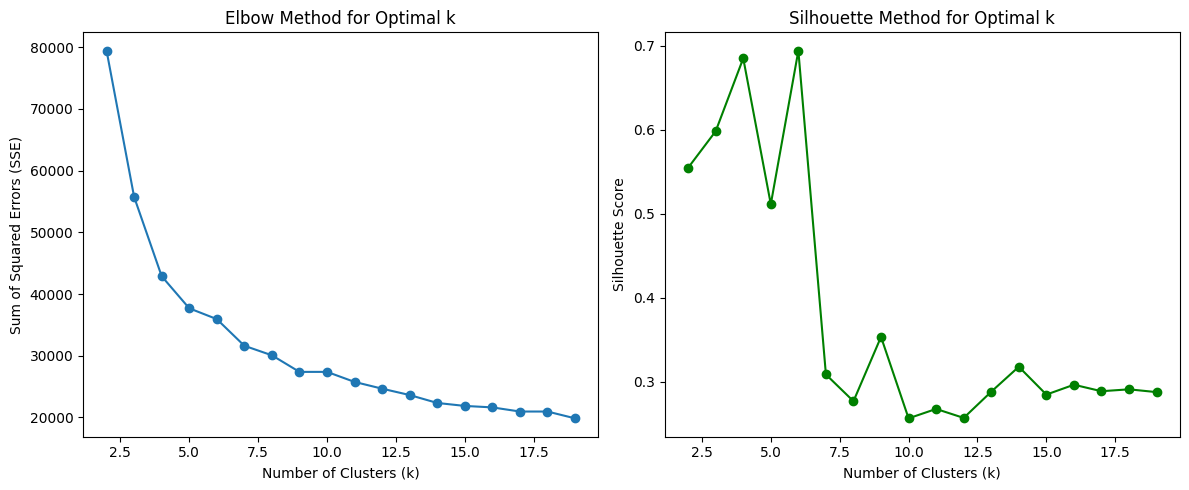

In [0]:
# ------------------------------
# STEP 5: Determine optimal number of clusters using Elbow and Silhouette method
# and visualize those metrics

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# Define a range for the number of clusters to try.
cluster_range = list(range(2, 20))  # Trying k from 2 to 10

sse_list = []            # For the Elbow method (sum of squared errors)
silhouette_scores = []   # For the Silhouette method

for k in cluster_range:
    # Configure KMeans with k clusters and using your feature column
    kmeans = KMeans(featuresCol="session_vec", k=k, seed=42)
    model = kmeans.fit(df_sessions)
    
    # Get predictions for the current model
    predictions = model.transform(df_sessions)
    
    # Sum of Squared Errors (SSE) from the training summary
    sse = model.summary.trainingCost
    sse_list.append(sse)
    
    # Evaluate the Silhouette score (using squaredEuclidean distance)
    evaluator = ClusteringEvaluator(featuresCol="session_vec", metricName="silhouette", distanceMeasure="squaredEuclidean")
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    print(f"Clusters: {k}, SSE: {sse:.2f}, Silhouette Score: {silhouette:.4f}")


# Plot the Elbow method and Silhouette scores
plt.figure(figsize=(12, 5))

# Elbow curve: k vs. SSE
plt.subplot(1, 2, 1)
plt.plot(cluster_range, sse_list, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")

# Silhouette score: k vs. Silhouette
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k")

plt.tight_layout()
plt.show()

In [0]:
# ------------------------------
# STEP 6: Cluster the session vectors using KMeans.
# k - Number of clusters determine in previous step
k = 6
kmeans = KMeans(featuresCol="session_vec", k=k, seed=42)
kmeans_model = kmeans.fit(df_sessions)
df_sessions = kmeans_model.transform(df_sessions)  # This adds a "prediction" column for clusters
df_sessions = df_sessions.withColumnRenamed("prediction", "cluster").cache()

In [0]:
df_sessions.printSchema()

root
 |-- session: string (nullable = true)
 |-- tokens: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- session_length: integer (nullable = false)
 |-- ua_category: string (nullable = true)
 |-- client_ip: string (nullable = true)
 |-- cmcd_sf: string (nullable = true)
 |-- session_vec: vector (nullable = true)
 |-- cluster: integer (nullable = false)



In [0]:
# Calculating fraction for visualization
fraction = 5000 / df_sessions.count()

# ------------------------------
# STEP 7: Reduce the session vectors to 2 dimensions for visualization with PCA.
# ------------------------------
pca = PCA(k=2, inputCol="session_vec", outputCol="pca_features")
viz_df = df_sessions.sample(fraction=fraction, seed=42)
pca_model = pca.fit(viz_df)
viz_df = pca_model.transform(viz_df)


# ------------------------------
# STEP 8: Collect a sample for visualization.
# We extract the 2D PCA components, the cluster, ua_category, and session length.
# ------------------------------
viz_df = viz_df.select("pca_features", "cluster", "session_length", "ua_category", 'cmcd_sf', 'client_ip').toPandas()
viz_df['cluster'] = viz_df['cluster'].astype(str)

# Extract the two PCA dimensions into separate columns.
viz_df["pca_x"] = viz_df["pca_features"].apply(lambda v: float(v[0]))
viz_df["pca_y"] = viz_df["pca_features"].apply(lambda v: float(v[1]))

# ------------------------------
# STEP 9: Create an interactive scatter plot using Plotly.
# The x and y axes are the PCA dimensions; cluster determines color; and hover shows session, ua_category, and session length.
# ------------------------------
import plotly.express as px

fig = px.scatter(
    viz_df,
    x="pca_x",
    y="pca_y",
    color="cluster",
    hover_data={"ua_category": True, "session_length": True,  'cmcd_sf' : True, 'client_ip': True},
    title="Session Clusters (PCA of Word2Vec Vectors)"
)

fig.show()

In [0]:
pca_model.explainedVariance

DenseVector([0.2972, 0.2174])

In [0]:
import plotly.express as px

fig = px.scatter(
    viz_df,
    x="pca_x",
    y="pca_y",
    #color="cluster",
    color="ua_category",
    hover_data={"ua_category": True, "session_length": True,  'cmcd_sf' : True, 'client_ip': True},
    title="Session Clusters (PCA of Word2Vec Vectors) event as by user agent category"
)

fig.show()

#Anomaly Detection

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml import Pipeline

In [0]:
#assembler = VectorAssembler(inputCols=feature_column, outputCol="features", handleInvalid="skip" )
# Standardize features using Spark's StandardScaler
feature_column = 'session_vec'


# Use StandardScaler. If 'session_vec' is sparse, consider withMean=False.
scaler = StandardScaler(inputCol=feature_column, 
                        outputCol="features_scaled", 
                        withMean=True,    # set to False if input is sparse
                        withStd=True)

# Configure GaussianMixture. Optionally, tune max iterations if needed.
gmm = GaussianMixture(featuresCol="features_scaled", 
                      k=k, 
                      seed=42,
                      maxIter=50)  # Adjust maxIter based on your data

# Create a pipeline for scaling and modeling
pipeline = Pipeline(stages=[scaler, gmm])

# Fit the model using the pipeline
# anomaly_model = pipeline.fit(df_sessions)
# as feature column already normalized, we do not need to use scaller in this case
anomaly_model = pipeline.fit(df_sessions)

In [0]:
# Transform the DataFrame to add a column for anomaly scores.
df_sessions = anomaly_model.transform(df_sessions).cache()
# Materialize the cache to ensure subsequent actions are fast.
df_sessions.count()  


from pyspark.ml.functions import vector_to_array
df_sessions = df_sessions.withColumn("max_prob", F.array_max(vector_to_array(F.col("probability"))))


# Define a threshold, e.g., the 1st percentile of max_prob (you may want to adjust this).
# Note: In Spark, we compute quantiles using approxQuantile.
quantiles = df_sessions.approxQuantile("max_prob", [0.01], 0.001)  # [0.01] is the quantile to compute (1st percentile), 0.001 is the relative error
print("Quantiles:", quantiles)
threshold = quantiles[0] if quantiles else 0.0

# Mark anomalies: if max_prob is below threshold, label as anomaly (1), else normal (0).
df_sessions = df_sessions.withColumn("anomaly_gmm", F.when(F.col("max_prob") <= threshold, 1).otherwise(0))

# Count the number of anomalies detected.
anomaly_count = df_sessions.filter(F.col("anomaly_gmm") == 1).count()
print(f"Number of anomalies detected: {anomaly_count}")

Quantiles: [0.16666666666666666]
Number of anomalies detected: 6749


In [0]:
df_sessions.printSchema()

root
 |-- session: string (nullable = true)
 |-- tokens: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- session_length: integer (nullable = false)
 |-- ua_category: string (nullable = true)
 |-- client_ip: string (nullable = true)
 |-- cmcd_sf: string (nullable = true)
 |-- session_vec: vector (nullable = true)
 |-- cluster: integer (nullable = false)
 |-- features_scaled: vector (nullable = true)
 |-- probability: vector (nullable = true)
 |-- prediction: integer (nullable = false)
 |-- max_prob: double (nullable = true)
 |-- anomaly_gmm: integer (nullable = false)



In [0]:
# Calculating fraction for visualization
fraction = 5000 / df_sessions.count()

# ------------------------------
# STEP 7: Reduce the session vectors to 2 dimensions for visualization with PCA.
# ------------------------------
pca = PCA(k=2, inputCol="session_vec", outputCol="pca_features")
viz_df = df_sessions.sample(fraction=fraction, seed=42).union(df_sessions.filter(df_sessions.anomaly_gmm == 1).limit(50))
pca_model = pca.fit(viz_df)
viz_df = pca_model.transform(viz_df)


# ------------------------------
# STEP 8: Collect a sample for visualization.
# We extract the 2D PCA components, the cluster, ua_category, and session length.
# ------------------------------
viz_df = viz_df.select("pca_features", "cluster", "session_length", "ua_category", 'cmcd_sf', 'client_ip', 'anomaly_gmm').toPandas()
viz_df['cluster'] = viz_df['cluster'].astype(str)

# Extract the two PCA dimensions into separate columns.
viz_df["pca_x"] = viz_df["pca_features"].apply(lambda v: float(v[0]))
viz_df["pca_y"] = viz_df["pca_features"].apply(lambda v: float(v[1]))
viz_df['anomaly_gmm'] = viz_df['anomaly_gmm'].astype(str)

import plotly.express as px

fig = px.scatter(
    viz_df,
    x="pca_x",
    y="pca_y",
    #color="cluster",
    color="anomaly_gmm",
    hover_data={"anomaly_gmm": True, "session_length": True,  'cmcd_sf' : True, 'client_ip': True},
    title="Session Clusters with anomalies"
)

fig.show()

# Writing data back to Hydrolix Cluster

In [0]:
import json
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from datetime import datetime
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from tqdm.notebook import tqdm
debug = True

def get_token():
  import requests
  import json
  username = '' #<USERNAME>
  password = '' #<PASSWORD>

  payload = {"username": username, "password": password}
  headers = {"Content-Type": "application/json"}
  response = requests.request("POST", base_url + oauth_path, headers=headers, json=payload)
  if response.status_code != 200:
    raise Exception(f"Failed to get token: {response.text}")
  return response.json()["auth_token"]["access_token"]


def post_data(data, token, base_url, ingest_path, max_retries=3):
    """
    Posts data to the HTTP collector with retry logic.
    """
    session = requests.Session()
    retries = Retry(
        total=max_retries,
        backoff_factor=1,
        status_forcelist=[500, 502, 503, 504],
        allowed_methods=["POST"]
    )
    adapter = HTTPAdapter(max_retries=retries)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    
    table = '<table>'
    transformation = '<transformation>'
    headers = {
        "Authorization": f"Bearer {token}",
        "content-type": "application/json",
        "x-hdx-table": table,
        "x-hdx-transform": transformation
    }
    
    # Convert the list of dictionaries to NDJSON (newline-delimited JSON)
    json_data = "\n".join(json.dumps(record) for record in data)
    
    response = requests.post(base_url + ingest_path, headers=headers, data=json_data)
    response.raise_for_status()  # Raises an error for non-2xx responses
    return response

def load_spark_data(spark_df, token, base_url, ingest_path, batch_size=10000):
    """
    Processes a Spark DataFrame and sends the data in batches to an HTTP endpoint.
    
    Parameters:
      spark_df (DataFrame): Input Spark DataFrame.
      token (str): Authorization token.
      base_url (str): Base URL for the HTTP collector.
      ingest_path (str): Ingest path to be appended to base_url.
      batch_size (int): Number of rows per batch (default is 1000).
      start_time (str, optional): A string for the "time" column; if None, current UTC time is used.
    """

    # Use current UTC time as an ISO-formatted string if no start_time is provided.
    #if start_time is None:
    #    start_time = datetime.utcnow().isoformat()
    
    # Convert the sparse vector in 'pca_features' to an array.
    df = spark_df.withColumn("pca_features_array", vector_to_array("pca_features"))
    
    # Extract the first two elements from the array as pca_x and pca_y.
    df = df.withColumn("pca_x", F.col("pca_features_array")[0].cast("float")) \
           .withColumn("pca_y", F.col("pca_features_array")[1].cast("float"))
    
    # Add the time column as a literal string.
    df = df.withColumn("time", F.lit(start_time.isoformat()))
    
    # Select the required columns, including pca_x and pca_y.
    df = df.select("time", "session", "session_length", "ua_category", 
                   "client_ip", "cmcd_sf", "cluster", "max_prob", "anomaly_gmm", "pca_x", "pca_y")
    
    total_rows = df.count()
    processed = 0
    batch = []
    
    # Iterate over the DataFrame rows in the driver with a progress bar.
    for row in tqdm(df.toLocalIterator(), total=total_rows, desc="Uploading batches"):
        batch.append(row.asDict())
        processed += 1
        
        if len(batch) >= batch_size:
            try:
                post_data(batch, token, base_url, ingest_path)
            except Exception as e:
                print(f"Error posting batch starting at row {processed - len(batch)}: {e}")
            batch = []
    
    # Process any remaining rows.
    if batch:
        try:
            post_data(batch, token, base_url, ingest_path)
        except Exception as e:
            print(f"Error posting final batch: {e}")
    
    print(f"Completed uploading {processed} rows in batches.")

# Example usage:
# load_spark_data(result, token, base_url, ingest_path)

In [0]:
base_url = "https://<hydrolix_cluster>"
ingest_path = "/ingest/event"
oauth_path = "/config/v1/login/"

token = get_token()
load_spark_data(result, token, base_url, ingest_path)